In [41]:
import os
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [42]:
DATA_FOLDER = "../data/NZZ_original"

# Root directory containing one subfolder per chart (defaults to CWD)
DATA_ROOT = os.getcwd()

FIELDS_TO_EXCLUDE = {
    "_rev",
    "department",
    "publication",
    "createdDate",
    "createdBy",
    "updatedDate",
    "updatedBy",
    "deactivateDate",
    "activateDate",
    "thumbnail",
    "data",
    "sources",
}

### Chart types

In [46]:
# ----- Helpers -----
def extract_data_from_json(json_path):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"Fehler beim Lesen von {json_path}: {e}")
        return None

def get_root_folder():
    preferred = os.path.abspath(DATA_FOLDER)
    if os.path.isdir(preferred):
        return preferred
    return DATA_ROOT

def extract_all_chart_types(data_folder=None):
    root = data_folder or get_root_folder()
    chart_types = set()

    for folder in sorted(os.listdir(root)):
        folder_path = os.path.join(root, folder)
        if not os.path.isdir(folder_path):
            continue

        json_file_path = os.path.join(folder_path, f"{folder}.json")
        if not os.path.isfile(json_file_path):
            continue

        json_info = extract_data_from_json(json_file_path)
        if not json_info:
            continue

        ct = json_info.get("options", {}).get("chartType")
        if ct:
            chart_types.add(ct)

    return sorted(chart_types)

In [44]:
if __name__ == "__main__":
    all_types = extract_all_chart_types()
    print("Gefundene Chart-Typen:", all_types)

Gefundene Chart-Typen: ['Area', 'Arrow', 'Bar', 'Dotplot', 'Line', 'StackedBar']


### Print all charts with json

In [ ]:
# ----- Helpers -----
def clean_json_for_output(json_info):
    """Entfernt unerwünschte Felder aus dem JSON für die Anzeige."""
    return {k: v for k, v in json_info.items() if k not in FIELDS_TO_EXCLUDE}

def extract_data_from_json(json_path):
    """Extrahiert Daten aus einer JSON-Datei und gibt das Dictionary zurück."""
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"Fehler beim Lesen von {json_path}: {e}")
        return None

def chart_type_filter(json_info, chart_type):
    """Filtert nach einem bestimmten Chart-Typ."""
    return json_info.get("options", {}).get("chartType") == chart_type

def has_date_series_option(json_info):
    """Filtert JSONs, die 'dateSeriesOptions' enthalten und nicht leer sind."""
    return bool(json_info.get("options", {}).get("dateSeriesOptions"))

def event_points(json_info):
    """True falls Events vorhanden sind."""
    return bool(json_info.get("events", {}))

# ----- Main -----
def main(filter_lst=None, data_folder=None):
    """
    Zeigt alle Charts (PNGs) und druckt bereinigtes JSON.
    - filter_lst: Liste von Funktionen f(json_info) -> bool für Filterlogik
    - data_folder: Root mit Unterordnern je Chart; Default = DATA_ROOT
    """
    root = data_folder or DATA_ROOT

    for folder in sorted(os.listdir(root)):
        folder_path = os.path.join(root, folder)
        if not os.path.isdir(folder_path):
            continue

        json_file_path = os.path.join(folder_path, f"{folder}.json")
        if not os.path.isfile(json_file_path):
            continue

        json_info = extract_data_from_json(json_file_path)
        if json_info is None:
            continue

        # Filter anwenden (alle müssen True sein)
        if filter_lst and not all(f(json_info) for f in filter_lst):
            continue

        image_path = os.path.join(folder_path, f"{folder}.png")
        if os.path.exists(image_path):
            try:
                img = mpimg.imread(image_path)
                plt.imshow(img)
                ct = json_info.get("options", {}).get("chartType")
                plt.title(f"{folder}  |  chartType: {ct}")
                plt.axis("off")
                plt.show()
            except Exception as e:
                print(f"Fehler beim Laden von {image_path}: {e}")
        else:
            print(f"Datei unter {image_path} existiert nicht.")

        cleaned = clean_json_for_output(json_info)
        print(f"\n=== {folder} (chartType={json_info.get('options', {}).get('chartType')}) ===")
        print(json.dumps(cleaned, indent=4, ensure_ascii=False))

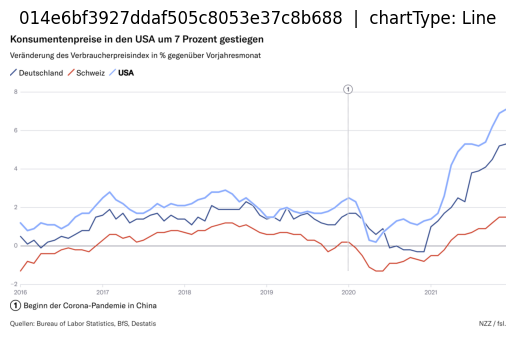


=== 014e6bf3927ddaf505c8053e37c8b688 (chartType=Line) ===
{
    "_id": "014e6bf3927ddaf505c8053e37c8b688",
    "acronym": "fsl.",
    "title": "Konsumentenpreise in den USA um 7 Prozent gestiegen",
    "tool": "chart",
    "allowDownloadData": false,
    "events": [
        {
            "type": "point",
            "date": "2019-12-29",
            "label": "Beginn der Corona-Pandemie in China"
        }
    ],
    "options": {
        "chartType": "Line",
        "hideAxisLabel": true,
        "highlightDataSeries": [
            2
        ],
        "highlightDataRows": [],
        "annotations": {
            "last": true,
            "max": false,
            "min": false
        },
        "barOptions": {
            "isBarChart": false,
            "forceBarsOnSmall": false
        },
        "dateSeriesOptions": {
            "interval": "auto",
            "labels": "many",
            "prognosisStart": null
        },
        "lineChartOptions": {
            "reverseYScale"

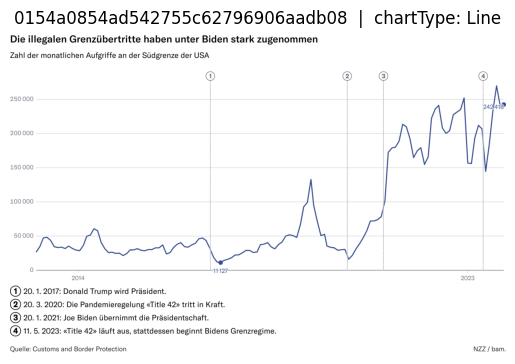


=== 0154a0854ad542755c62796906aadb08 (chartType=Line) ===
{
    "_id": "0154a0854ad542755c62796906aadb08",
    "acronym": "bam.",
    "title": "Die illegalen Grenzübertritte haben unter Biden stark zugenommen",
    "tool": "chart",
    "allowDownloadData": false,
    "options": {
        "chartType": "Line",
        "hideAxisLabel": true,
        "annotations": {
            "max": false,
            "last": true,
            "min": true
        },
        "barOptions": {
            "isBarChart": false,
            "forceBarsOnSmall": false
        },
        "dateSeriesOptions": {
            "interval": "year",
            "prognosisStart": null,
            "labels": "few"
        },
        "lineChartOptions": {
            "reverseYScale": false,
            "lineInterpolation": "linear",
            "isStockChart": false
        },
        "dotplotOptions": {},
        "arrowOptions": {
            "colorScheme": 0
        },
        "highlightDataSeries": [],
        "colorOve

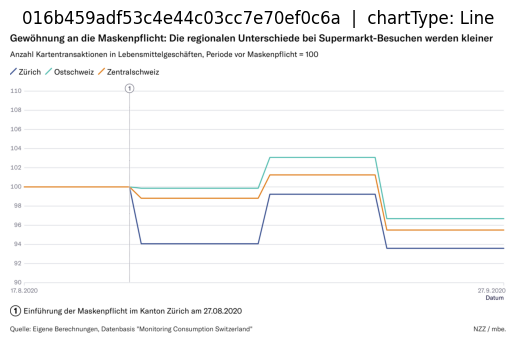


=== 016b459adf53c4e44c03cc7e70ef0c6a (chartType=Line) ===
{
    "_id": "016b459adf53c4e44c03cc7e70ef0c6a",
    "acronym": "mbe.",
    "allowDownloadData": false,
    "events": [
        {
            "type": "point",
            "date": "26.08.2020",
            "label": "Einführung der Maskenpflicht im Kanton Zürich am 27.08.2020"
        }
    ],
    "options": {
        "chartType": "Line",
        "hideAxisLabel": false,
        "highlightDataSeries": [],
        "highlightDataRows": [],
        "annotations": {},
        "barOptions": {
            "isBarChart": false,
            "forceBarsOnSmall": false
        },
        "dateSeriesOptions": {
            "interval": "auto",
            "labels": "few",
            "prognosisStart": null
        },
        "lineChartOptions": {
            "reverseYScale": false,
            "lineInterpolation": "linear",
            "isStockChart": false,
            "minValue": 90,
            "maxValue": 110
        },
        "areaChartOp

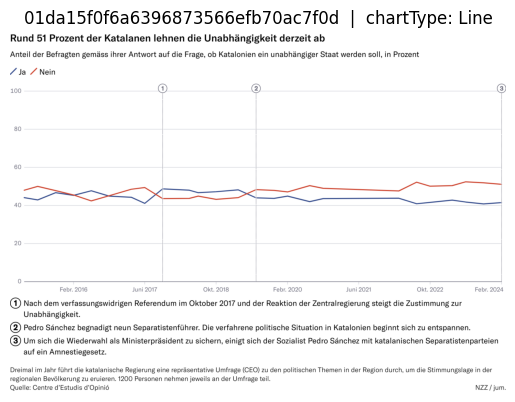


=== 01da15f0f6a6396873566efb70ac7f0d (chartType=Line) ===
{
    "_id": "01da15f0f6a6396873566efb70ac7f0d",
    "acronym": "jum.",
    "title": "Rund 51 Prozent der Katalanen lehnen die Unabhängigkeit derzeit ab",
    "tool": "chart",
    "allowDownloadData": false,
    "events": [
        {
            "type": "point",
            "date": "10-2017",
            "label": "Nach dem verfassungswidrigen Referendum im Oktober 2017 und der Reaktion der Zentralregierung steigt die Zustimmung zur Unabhängigkeit."
        },
        {
            "type": "point",
            "date": "7-2019",
            "label": "Pedro Sánchez begnadigt neun Separatistenführer. Die verfahrene politische Situation in Katalonien beginnt sich zu entspannen."
        },
        {
            "type": "point",
            "date": "2-2024",
            "label": "Um sich die Wiederwahl als Ministerpräsident zu sichern, einigt sich der Sozialist Pedro Sánchez mit katalanischen Separatistenparteien auf ein Amnestiegese

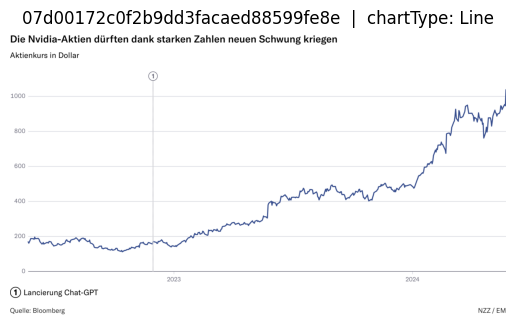


=== 07d00172c0f2b9dd3facaed88599fe8e (chartType=Line) ===
{
    "_id": "07d00172c0f2b9dd3facaed88599fe8e",
    "acronym": "EM",
    "allowDownloadData": false,
    "events": [
        {
            "type": "point",
            "date": "30.11.2022",
            "label": "Lancierung Chat-GPT"
        }
    ],
    "options": {
        "chartType": "Line",
        "hideAxisLabel": false,
        "highlightDataSeries": [],
        "highlightDataRows": [],
        "annotations": {},
        "barOptions": {
            "isBarChart": false,
            "forceBarsOnSmall": false
        },
        "dateSeriesOptions": {
            "interval": "auto",
            "labels": "many",
            "prognosisStart": null
        },
        "lineChartOptions": {
            "yScaleType": "linear",
            "reverseYScale": false,
            "lineInterpolation": "linear",
            "isStockChart": false
        },
        "areaChartOptions": {
            "areaInterpolation": "linear",
         

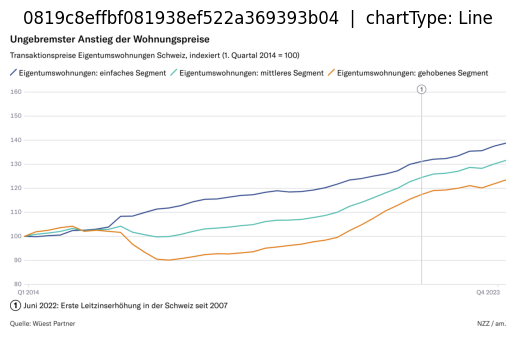


=== 0819c8effbf081938ef522a369393b04 (chartType=Line) ===
{
    "_id": "0819c8effbf081938ef522a369393b04",
    "acronym": "am.",
    "allowDownloadData": false,
    "events": [
        {
            "type": "point",
            "date": "2022-Q2",
            "label": "Juni 2022: Erste Leitzinserhöhung in der Schweiz seit 2007"
        }
    ],
    "options": {
        "chartType": "Line",
        "hideAxisLabel": false,
        "highlightDataSeries": [],
        "highlightDataRows": [],
        "annotations": {},
        "barOptions": {
            "isBarChart": false,
            "forceBarsOnSmall": false
        },
        "dateSeriesOptions": {
            "interval": "quarter",
            "labels": "few",
            "prognosisStart": null
        },
        "lineChartOptions": {
            "yScaleType": "linear",
            "reverseYScale": false,
            "lineInterpolation": "linear",
            "isStockChart": false,
            "minValue": 80,
            "maxValue": 1

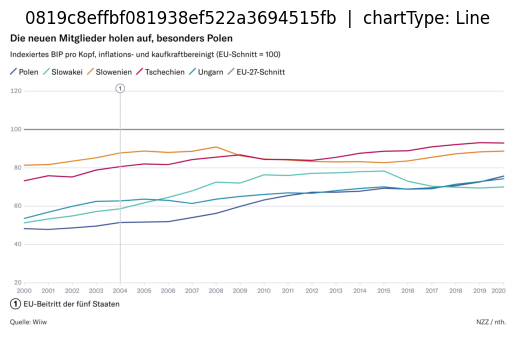


=== 0819c8effbf081938ef522a3694515fb (chartType=Line) ===
{
    "_id": "0819c8effbf081938ef522a3694515fb",
    "acronym": "nth.",
    "allowDownloadData": false,
    "active": true,
    "tool": "chart",
    "title": "Die neuen Mitglieder holen auf, besonders Polen",
    "subtitle": "Indexiertes BIP pro Kopf, inflations- und kaufkraftbereinigt (EU-Schnitt = 100) ",
    "events": [
        {
            "type": "point",
            "label": "EU-Beitritt der fünf Staaten",
            "date": "2004"
        }
    ],
    "options": {
        "annotations": {},
        "areaChartOptions": {
            "areaInterpolation": "linear",
            "stackType": "zero"
        },
        "arrowOptions": {
            "colorScheme": 0,
            "invertColorScheme": false
        },
        "barOptions": {
            "isBarChart": false,
            "forceBarsOnSmall": false
        },
        "chartType": "Line",
        "colorOverwritesRows": [],
        "colorOverwritesSeries": [
         

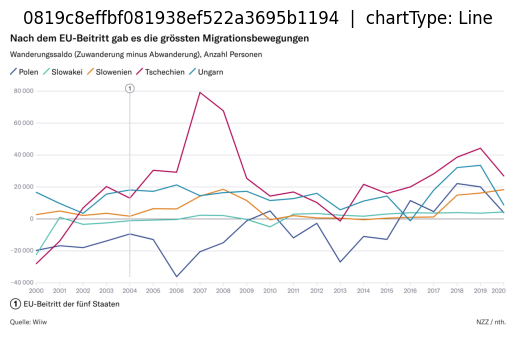


=== 0819c8effbf081938ef522a3695b1194 (chartType=Line) ===
{
    "_id": "0819c8effbf081938ef522a3695b1194",
    "acronym": "nth.",
    "allowDownloadData": false,
    "events": [
        {
            "type": "point",
            "date": "2004",
            "label": "EU-Beitritt der fünf Staaten"
        }
    ],
    "options": {
        "chartType": "Line",
        "hideAxisLabel": false,
        "highlightDataSeries": [],
        "highlightDataRows": [],
        "annotations": {},
        "barOptions": {
            "isBarChart": false,
            "forceBarsOnSmall": false
        },
        "dateSeriesOptions": {
            "interval": "auto",
            "labels": "many",
            "prognosisStart": null
        },
        "lineChartOptions": {
            "yScaleType": "linear",
            "reverseYScale": false,
            "lineInterpolation": "linear",
            "isStockChart": false
        },
        "areaChartOptions": {
            "areaInterpolation": "linear",
    

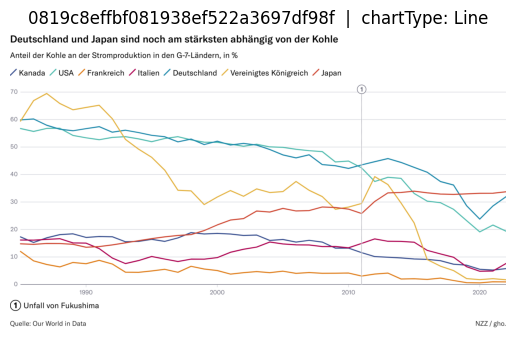


=== 0819c8effbf081938ef522a3697df98f (chartType=Line) ===
{
    "_id": "0819c8effbf081938ef522a3697df98f",
    "allowDownloadData": false,
    "events": [
        {
            "type": "point",
            "date": "2011",
            "label": "Unfall von Fukushima"
        }
    ],
    "options": {
        "chartType": "Line",
        "hideAxisLabel": false,
        "highlightDataSeries": [],
        "highlightDataRows": [],
        "annotations": {},
        "barOptions": {
            "isBarChart": false,
            "forceBarsOnSmall": false
        },
        "dateSeriesOptions": {
            "interval": "auto",
            "labels": "many",
            "prognosisStart": null
        },
        "lineChartOptions": {
            "yScaleType": "linear",
            "reverseYScale": false,
            "lineInterpolation": "linear",
            "isStockChart": false
        },
        "areaChartOptions": {
            "areaInterpolation": "linear",
            "stackType": "zero"
   

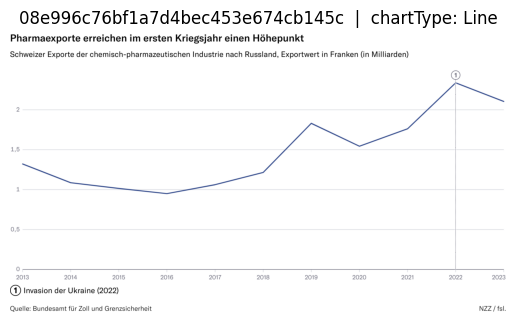


=== 08e996c76bf1a7d4bec453e674cb145c (chartType=Line) ===
{
    "_id": "08e996c76bf1a7d4bec453e674cb145c",
    "acronym": "fsl.",
    "allowDownloadData": false,
    "active": true,
    "tool": "chart",
    "title": "Pharmaexporte erreichen im ersten Kriegsjahr einen Höhepunkt",
    "subtitle": "Schweizer Exporte der chemisch-pharmazeutischen Industrie nach Russland, Exportwert in Franken",
    "events": [
        {
            "type": "point",
            "label": "Invasion der Ukraine (2022)",
            "date": "2022-01-01"
        }
    ],
    "options": {
        "annotations": {},
        "areaChartOptions": {
            "areaInterpolation": "linear",
            "stackType": "zero"
        },
        "arrowOptions": {
            "colorScheme": 0,
            "invertColorScheme": false
        },
        "barOptions": {
            "isBarChart": false,
            "forceBarsOnSmall": false
        },
        "chartType": "Line",
        "colorOverwritesRows": [],
        "col

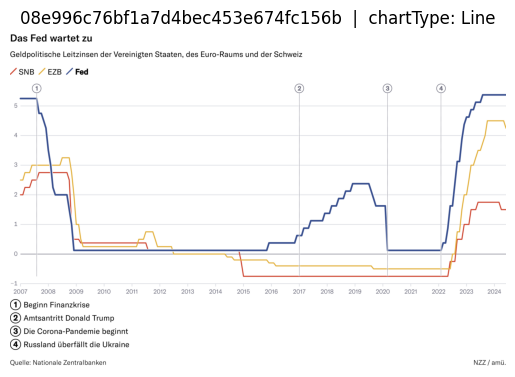


=== 08e996c76bf1a7d4bec453e674fc156b (chartType=Line) ===
{
    "_id": "08e996c76bf1a7d4bec453e674fc156b",
    "title": "Das Fed wartet zu",
    "tool": "chart",
    "acronym": "amü.",
    "allowDownloadData": false,
    "events": [
        {
            "type": "point",
            "date": "03-2020",
            "label": "Die Corona-Pandemie beginnt"
        },
        {
            "type": "point",
            "date": "02-2022",
            "label": "Russland überfällt die Ukraine"
        },
        {
            "type": "point",
            "date": "2007-08",
            "label": "Beginn Finanzkrise"
        },
        {
            "type": "point",
            "date": "2017-01",
            "label": "Amtsantritt Donald Trump"
        }
    ],
    "options": {
        "chartType": "Line",
        "hideAxisLabel": true,
        "highlightDataSeries": [
            2
        ],
        "highlightDataRows": [],
        "annotations": {},
        "barOptions": {
            "isBarChar

In [ ]:
if __name__ == "__main__":
    filter_functions = [
        lambda json_info: chart_type_filter(json_info, chart_type="Line"),
        has_date_series_option,
        event_points
    ]
    main(filter_lst=filter_functions, data_folder=DATA_FOLDER)